<a href="https://colab.research.google.com/github/lelyashashlyk/DataScienceLearning/blob/main/pandas/pandas_series_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Task 1

Данн массив случайных целых чисел.
* Преобразуйте его в серию.
* Выведите отдельно массив с индексами и массив со значениями серии.
* Измените индексы на упорядоченное множество чисел начиная с 1. [1, 2, 3,...]
* Постройте гистограмму распрпеделения элементов серии.
* Определите, на сколько процентов отличается количество четных от нечетных Надо помнить, что булева фильтрация с `pd.Series` работает в точности также как и с `np.ndarray`.

In [2]:
arr = np.random.randint(1, 40, 40)
ser = pd.Series(arr)
ser

,0
0,34
1,25
2,14
3,28
4,14
5,13
6,37
7,26
8,26
9,17


In [3]:
(ser.index, ser.values)

(RangeIndex(start=0, stop=40, step=1),
 array([34, 25, 14, 28, 14, 13, 37, 26, 26, 17, 33, 33, 29, 30, 29, 18,  3,
        35, 15,  5, 11, 28,  2, 17, 15, 15, 25, 21, 24, 16, 31, 17,  5,  3,
        16, 35, 33, 35, 19, 30]))

In [4]:
ser.index = [i for i in range(1, 41)]
ser.index

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40],
      dtype='int64')

<Axes: ylabel='Count'>

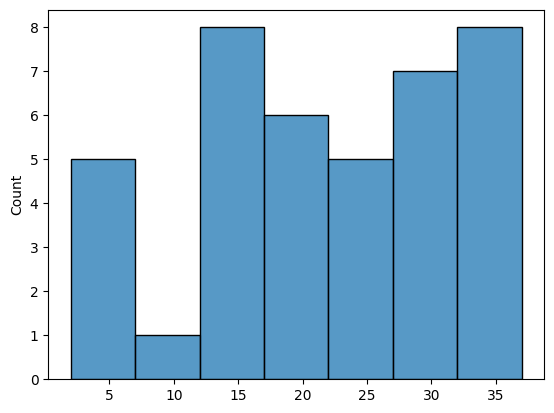

In [5]:
sns.histplot(ser)

# Task 2

Дан список имен и баллов за тест.
* Сгенерите из представленных данныъх серию, где в качестве индекса будет имя, а в качестве значения - балл. Присвойте серии имя test.
* Отсортируйте полученную серию по убыванию используя функцию `ser.sort_values(ascending=False)`
* Постройте `sns.barplot`

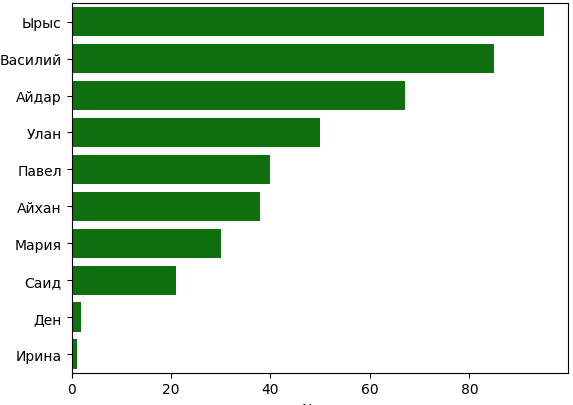

In [6]:
names = ['Ырыс', 'Василий', 'Мария', 'Павел', 'Улан', 'Айдар', 'Саид', 'Ирина', 'Ден', 'Айхан']
score = [95, 85, 30, 40, 50, 67, 21, 1, 2, 38]

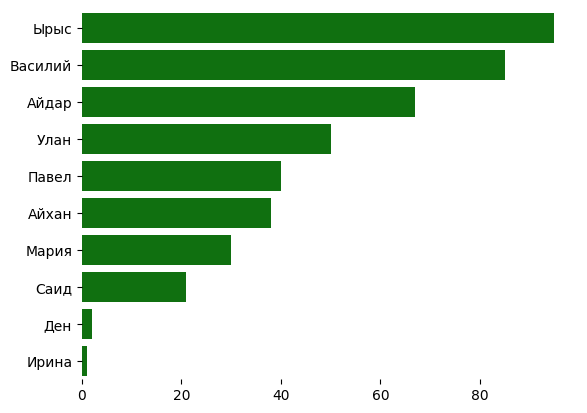

In [7]:
from binascii import Incomplete
test = pd.Series(score)
test.index = names
test.sort_values(ascending=False, inplace=True)
plt.figsize=(8,)
sns.barplot(test, color='green', orient='h')
sns.despine(left=True, bottom=True)

# Task 3
Напишите функцию, на вход которой подается словарь и лист с желаемым расположением индексов. Функция возвращает серию.

С помощью данной функции остройте серию так, чтобы индексы были расположены в порядке: e, a, c, b, d

In [8]:
your_dict = {'a': 1, 'b': 10, 'c': 21, 'd': 12, 'e': 31}

In [9]:
def ger_Series(d: dict) -> pd.Series:
  ind = list(d.keys())
  ser = pd.Series(d.values())
  ser.index = np.random.choice(ind, size=len(your_dict))
  return ser
ger_Series(your_dict)

,0
e,1
b,10
e,21
a,12
a,31


In [10]:
def ger_Series2(d: dict, l:list) -> pd.Series:
  ser = pd.Series(d)
  return ser.reindex(l)


ger_Series2(your_dict, ['e', 'a', 'c', 'b', 'd'])

,0
e,31
a,1
c,21
b,10
d,12


# Task 4

Даны два массива.
* Сформируйте из них словарь.
* Напишите функцию, которая получает на вход словарь и возвращает серию.
* Постройте серию `my_ser` из сформированного словаря применив написанную функцию.
* Добавьте в серию еще один индекс g. Индексу g присвойте значение 10.

In [11]:
l_val = [2, 3, 4, 5, 3, 2]
l_keys = ['a', 'b', 'c', 'd', 'e', 'f']

my_dict = {k:v for k, v in zip(l_keys, l_val)}
my_dict

{'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 3, 'f': 2}

In [12]:
def dict_to_series(dct):
  return pd.Series(dct)

In [13]:
ser = dict_to_series(my_dict)

In [14]:
ser['g'] = 10
ser

,0
a,2
b,3
c,4
d,5
e,3
f,2
g,10


# Task 5

Проверьте, все ли значения серии заполнены?
* Напишите функцию, которая получает на вход серию и возвращает одно значение:
  1. True - если в серии пропусков нет
  2. False - если есть хотя бы один пропуск.
* Почистите серию от пропусков.

In [15]:
ser_n = pd.Series([3, 4, 7, 3, 4, np.nan, 4, 3, 2])

In [16]:
def TFSer_check(s: pd.Series) -> bool:
  return (s.isnull().sum() == 0).item() # s.hasnans()

In [17]:
TFSer_check(ser_n)

False

In [18]:
ser_n = ser_n[ser_n.notnull()]
ser_n

,0
0,3.0
1,4.0
2,7.0
3,3.0
4,4.0
6,4.0
7,3.0
8,2.0


# Task 6

Мы имеем несколько серий, где хранятся по дням недели количества посещений определенным пользователем сайта за день.

* Составте новую серию, которая содержит по дням суммарное число посещений за 3 недели.
* Составте новую серию, которая содержит по дням усредненное число посещений за 3 недели.
* Постройте барплот со средним количеством посещением пользователя по дням недели.
* Составте новую серию, которая содержит по дням максимальное количество посещений за 3 недели.

In [19]:
index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
week_1 = pd.Series([1, 12, 41, 1, 3, 6, 3], index=index)
week_2 = pd.Series([4, 7, 3, 5, 7, 21, 5], index=index)
week_3 = pd.Series([9, 2, 5, 15, 6, 10, 2], index=index)

In [20]:
all_weeks = week_2 + week_1 + week_3
all_weeks

,0
Пн,14
Вт,21
Ср,49
Чт,21
Пт,16
Сб,37
Вс,10


In [21]:
mean_weeks = round(all_weeks/3).astype(int)

In [22]:
m2 = pd.Series(np.concatenate([[week_1], [week_2], [week_3]]).mean(axis=0).round(0), index = index)
display(m2, mean_weeks)

,0
Пн,5.0
Вт,7.0
Ср,16.0
Чт,7.0
Пт,5.0
Сб,12.0
Вс,3.0


,0
Пн,5
Вт,7
Ср,16
Чт,7
Пт,5
Сб,12
Вс,3


In [24]:
ser_mm = pd.Series(np.concatenate([[week_1], [week_2], [week_3]]).max(axis=0).round(0), index = index)
ser_mm

,0
Пн,9
Вт,12
Ср,41
Чт,15
Пт,7
Сб,21
Вс,5


<Axes: >

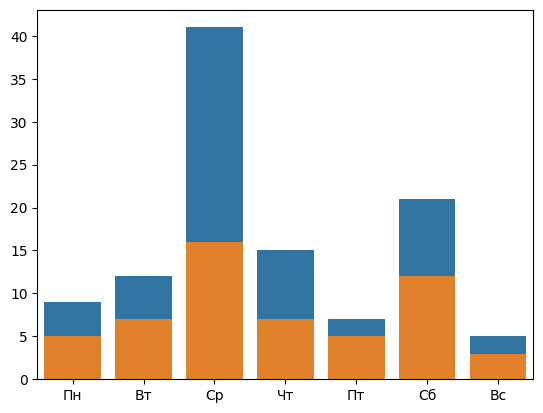

In [26]:
sns.barplot(ser_mm)
sns.barplot(mean_weeks)

# Task_7

Мы сгенерили две серии со стоимостями земельных участков и с площадями участков в сотках. Индексы содержат идентификаторы никальных участков. Таким образом, если мы знаем стоимость конкретного участка, то мы можем не знать его площадь.
* Получите серию со стоимостями одной сотки для каждого участка
* Получите список всех участков, по которым удалось вычислить стоимость земли за одну сотку.
* Почистите полученную серию от пропусков. Почему появились пропуски?
* Постройте Барплот по стоимостям за сотку для участков.

In [27]:
ind_price = ['Object_' + str(i) for i in [1, 2, 4, 5, 7, 9, 10, 11, 12, 13]]
ind_squere = ['Object_' + str(i) for i in [1, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14]]
price = np.random.randint(20000, 100000, len(ind_price))
squere = np.random.randint(5, 12, len(ind_squere))

price = pd.Series(price, index = ind_price)
squere = pd.Series(squere, index = ind_squere)

In [28]:
price_for_1 = squere/price
price_for_1

,0
Object_1,0.000164
Object_10,NaN
Object_11,0.000278
Object_12,0.000133
Object_13,0.000229
Object_14,NaN
Object_2,NaN
Object_3,NaN
Object_4,0.000127
Object_5,NaN


In [29]:
price_for_1[price_for_1.notnull()]

,0
Object_1,0.000164
Object_11,0.000278
Object_12,0.000133
Object_13,0.000229
Object_4,0.000127
Object_7,0.000197
Object_9,0.000173


In [30]:
price_for_1 = price_for_1[price_for_1.notnull()]
price_for_1

,0
Object_1,0.000164
Object_11,0.000278
Object_12,0.000133
Object_13,0.000229
Object_4,0.000127
Object_7,0.000197
Object_9,0.000173


<Axes: >

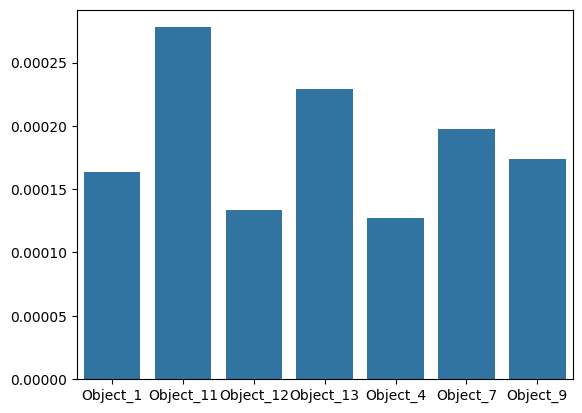

In [31]:
sns.barplot(price_for_1)